# Лабораторная 8

## Задание
### С помощью предобученной модели StableDiffusion сгенерировать фотографии себя в разном окружении (в стиле киберпанка, из металла и тд).
#### Должно сохраниться ваше лицо!!!
#### Показать одно качественное изображение и еще 5


In [1]:
import torch
from diffusers import StableDiffusionPipeline
from diffusers.schedulers import DPMSolverMultistepScheduler
from PIL import Image
import matplotlib.pyplot as plt

pipe= StableDiffusionPipeline.from_pretrained(
    "./stable-diffusion-1-5",
    torch_dtype=torch.float16,
    local_files_only=True,
    use_safetensors=True,
    safety_checker=None,
    requires_safety_checker=False
).to("cuda")

pipe.scheduler= DPMSolverMultistepScheduler.from_config(pipe.scheduler.config, use_karras_sigmas=True)

pipe.load_ip_adapter(
    "./my_adapter",
    subfolder="",
    weight_name="ip-adapter-plus-face_sd15.safetensors",
    image_encoder_folder="models/image_encoder",
    local_files_only=True
)

pipe.set_ip_adapter_scale(0.95)
my_img = Image.open("3.jpg")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

photo of a man in a cyberpunk city wearing authentic costume, neon lights, high quality, realism


  0%|          | 0/200 [00:00<?, ?it/s]

photo of a man made of solid chrome metal, dark background, high quality, realism


  0%|          | 0/200 [00:00<?, ?it/s]

photo of a man as a futuristic space marine, high quality, realism


...

  0%|          | 0/200 [00:00<?, ?it/s]

photo of a man wearing a virtual reality headset in a neon room, high quality, realism


  0%|          | 0/200 [00:00<?, ?it/s]

photo of a man as a medieval king on a throne, high quality, realism


  0%|          | 0/200 [00:00<?, ?it/s]

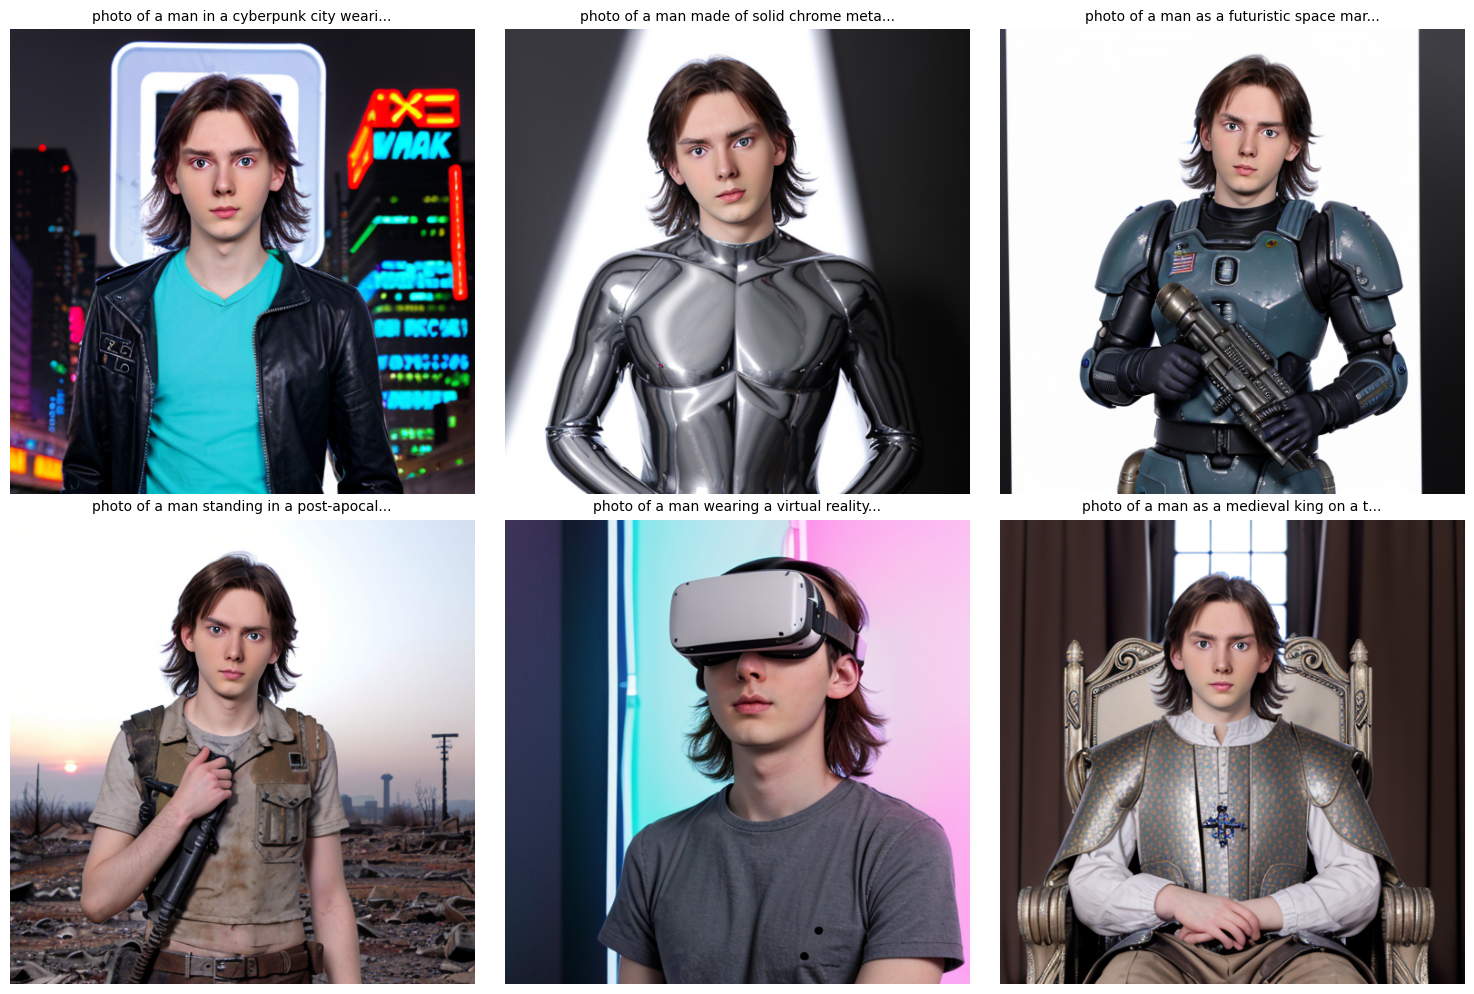

In [2]:
my_prompts = [
    "photo of a man in a cyberpunk city wearing authentic costume, neon lights, high quality, realism",
    "photo of a man made of solid chrome metal, dark background, high quality, realism",
    "photo of a man as a futuristic space marine, high quality, realism",
    "photo of a man standing in a post-apocalyptic wasteland wearing authentic costume, high quality, realism",
    "photo of a man wearing a virtual reality headset in a neon room, high quality, realism",
    "photo of a man as a medieval king on a throne, high quality, realism"
]
imgs = []

for p in my_prompts:
    print(f"{p}")

    if "virtual reality headset" in p:
        pipe.set_ip_adapter_scale(0.5)
    else:
        pipe.set_ip_adapter_scale(0.95)

    image = pipe(
        prompt=p,
        ip_adapter_image=my_img,
        num_inference_steps=200,
        guidance_scale=7.5
    ).images[0]
    imgs.append((image, p))

pipe.unload_ip_adapter()

fig,axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for (img, p), ax in zip(imgs, axes):
    ax.imshow(img)
    ax.axis("off")
    short_title = p.split(",")[0][:40] + "..."
    ax.set_title(short_title, fontsize=10)

plt.tight_layout()
plt.show()

### Показать изображения, сгенерированные по тексту “<ваш пол> in a forest”, “<ваш пол> in a city”, “<ваш пол> in a beach”, с уточнениями “high quality, realism”
#### Не использовать трансляцию из изображения в изображение
#### Не использовать негативные промпты


man in a forest, high quality, realism


  0%|          | 0/50 [00:00<?, ?it/s]

man in a city, high quality, realism


  0%|          | 0/50 [00:00<?, ?it/s]

man in a beach, high quality, realism


  0%|          | 0/50 [00:00<?, ?it/s]

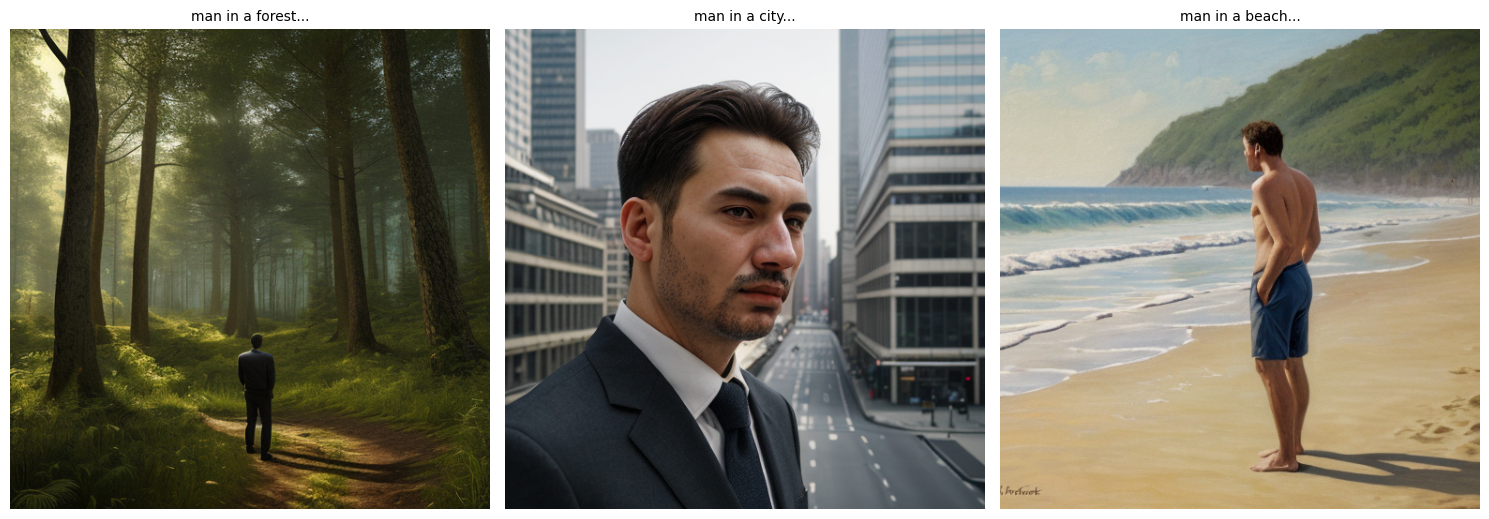

In [3]:
generic_prompts = [
    "man in a forest, high quality, realism",
    "man in a city, high quality, realism",
    "man in a beach, high quality, realism"
]
imgs = []

for p in generic_prompts:
    print(f"{p}")
    image = pipe(
        prompt=p,
        num_inference_steps=50,
        guidance_scale=7.5
    ).images[0]
    imgs.append((image, p))

fig, axes = plt.subplots(1, 3, figsize=(15, 15))
axes = axes.flatten()

for (img, p), ax in zip(imgs, axes):
    ax.imshow(img)
    ax.axis("off")
    short_title = p.split(",")[0][:40] + "..."
    ax.set_title(short_title, fontsize=10)

plt.tight_layout()
plt.show()